In [16]:
import subprocess
import sys

subprocess.check_call([sys.executable, "-m", "pip", "install", "prophet"])

0

In [17]:
import pandas as pd
import numpy as np
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


In [5]:
df = pd.read_csv('Superstore_Final_Clean.csv')
df['Order Date'] = pd.to_datetime(df['Order Date'])

daily_sales = df.groupby('Order Date')['Sales'].sum().reset_index()
daily_sales.columns = ['ds', 'y']

print(f"Data shape: {daily_sales.shape}")
print(f"Date range: {daily_sales['ds'].min()} to {daily_sales['ds'].max()}")
print(daily_sales.head())

Data shape: (1237, 2)
Date range: 2014-01-02 00:00:00 to 2017-12-30 00:00:00
          ds         y
0 2014-01-02   468.900
1 2014-01-03  2203.151
2 2014-01-04   119.888
3 2014-01-06  5188.520
4 2014-01-07   601.024


In [6]:
train_size = int(len(daily_sales) * 0.8)

train_data = daily_sales[:train_size].copy()
test_data = daily_sales[train_size:].copy()

print(f"Train size: {len(train_data)}")
print(f"Test size: {len(test_data)}")
print(f"Train date: {train_data['ds'].min()} to {train_data['ds'].max()}")
print(f"Test date: {test_data['ds'].min()} to {test_data['ds'].max()}")

Train size: 989
Test size: 248
Train date: 2014-01-02 00:00:00 to 2017-03-28 00:00:00
Test date: 2017-03-29 00:00:00 to 2017-12-30 00:00:00


In [7]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    interval_width=0.95
)

model.fit(train_data)

print("Model trained successfully")

18:14:12 - cmdstanpy - INFO - Chain [1] start processing
18:14:13 - cmdstanpy - INFO - Chain [1] done processing


Model trained successfully


In [8]:
future = model.make_future_dataframe(periods=len(test_data))
forecast = model.predict(future)

forecast_test = forecast.iloc[train_size:train_size+len(test_data)].copy()

print("Predictions made")
print(forecast_test[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head())

Predictions made
            ds         yhat   yhat_lower   yhat_upper
989 2017-03-29  1733.538503 -2583.650079  6066.472052
990 2017-03-30  1919.441126 -2363.882711  6088.264151
991 2017-03-31  2126.251576 -2039.577187  6559.021305
992 2017-04-01  1667.333233 -2561.097852  6100.328375
993 2017-04-02  1747.371250 -2681.035410  6166.609885


In [9]:
mae = mean_absolute_error(test_data['y'], forecast_test['yhat'])
rmse = np.sqrt(mean_squared_error(test_data['y'], forecast_test['yhat']))
mape = np.mean(np.abs((test_data['y'] - forecast_test['yhat']) / test_data['y'])) * 100

print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

Mean Absolute Error (MAE): $1753.84
Root Mean Squared Error (RMSE): $2427.05
Mean Absolute Percentage Error (MAPE): 800.46%


In [12]:
param_grid = {
    'seasonality_mode': ['additive', 'multiplicative'],
    'seasonality_prior_scale': [10, 20],
    'changepoint_prior_scale': [0.05, 0.1]
}

results = []

for seasonality_mode in param_grid['seasonality_mode']:
    for seasonality_prior_scale in param_grid['seasonality_prior_scale']:
        for changepoint_prior_scale in param_grid['changepoint_prior_scale']:
            
            model = Prophet(
                seasonality_mode=seasonality_mode,
                seasonality_prior_scale=seasonality_prior_scale,
                changepoint_prior_scale=changepoint_prior_scale,
                yearly_seasonality=True,
                weekly_seasonality=True
            )
            
            model.fit(train_data)
            forecast = model.predict(future)
            forecast_test = forecast.iloc[train_size:train_size+len(test_data)].copy()
            
            mae = mean_absolute_error(test_data['y'], forecast_test['yhat'])
            
            results.append({
                'seasonality_mode': seasonality_mode,
                'seasonality_prior_scale': seasonality_prior_scale,
                'changepoint_prior_scale': changepoint_prior_scale,
                'MAE': mae
            })

results_df = pd.DataFrame(results)
print("Tuning complete")
print(results_df.sort_values('MAE'))

18:15:51 - cmdstanpy - INFO - Chain [1] start processing
18:15:51 - cmdstanpy - INFO - Chain [1] done processing
18:15:51 - cmdstanpy - INFO - Chain [1] start processing
18:15:51 - cmdstanpy - INFO - Chain [1] done processing
18:15:52 - cmdstanpy - INFO - Chain [1] start processing
18:15:52 - cmdstanpy - INFO - Chain [1] done processing
18:15:53 - cmdstanpy - INFO - Chain [1] start processing
18:15:53 - cmdstanpy - INFO - Chain [1] done processing
18:15:53 - cmdstanpy - INFO - Chain [1] start processing
18:15:53 - cmdstanpy - INFO - Chain [1] done processing
18:15:54 - cmdstanpy - INFO - Chain [1] start processing
18:15:54 - cmdstanpy - INFO - Chain [1] done processing
18:15:54 - cmdstanpy - INFO - Chain [1] start processing
18:15:54 - cmdstanpy - INFO - Chain [1] done processing
18:15:55 - cmdstanpy - INFO - Chain [1] start processing
18:15:55 - cmdstanpy - INFO - Chain [1] done processing


Tuning complete
  seasonality_mode  seasonality_prior_scale  changepoint_prior_scale  \
0         additive                       10                     0.05   
2         additive                       20                     0.05   
6   multiplicative                       20                     0.05   
4   multiplicative                       10                     0.05   
7   multiplicative                       20                     0.10   
5   multiplicative                       10                     0.10   
3         additive                       20                     0.10   
1         additive                       10                     0.10   

           MAE  
0  1753.835224  
2  1753.972292  
6  1758.126062  
4  1761.504908  
7  1810.570308  
5  1817.531008  
3  1833.041945  
1  1835.711618  


In [13]:
best_params = results_df.loc[results_df['MAE'].idxmin()]

print("Best Parameters:")
print(f"Seasonality Mode: {best_params['seasonality_mode']}")
print(f"Seasonality Prior Scale: {best_params['seasonality_prior_scale']}")
print(f"Seasonality Reg: {best_params['seasonality_reg']}")
print(f"Changepoint Prior Scale: {best_params['changepoint_prior_scale']}")
print(f"Best MAE: ${best_params['MAE']:.2f}")

best_model = Prophet(
    seasonality_mode=best_params['seasonality_mode'],
    seasonality_prior_scale=best_params['seasonality_prior_scale'],
    seasonality_reg=best_params['seasonality_reg'],
    changepoint_prior_scale=best_params['changepoint_prior_scale'],
    yearly_seasonality=True,
    weekly_seasonality=True
)

best_model.fit(train_data)
print("Best model trained")

Best Parameters:
Seasonality Mode: additive
Seasonality Prior Scale: 10


KeyError: 'seasonality_reg'

18:19:18 - cmdstanpy - INFO - Chain [1] start processing
18:19:18 - cmdstanpy - INFO - Chain [1] done processing
18:19:18 - cmdstanpy - INFO - Chain [1] start processing
18:19:18 - cmdstanpy - INFO - Chain [1] done processing


CPS=0.001, SPS=1, MAE=2030.93


18:19:19 - cmdstanpy - INFO - Chain [1] start processing
18:19:19 - cmdstanpy - INFO - Chain [1] done processing


CPS=0.001, SPS=5, MAE=2019.55


18:19:19 - cmdstanpy - INFO - Chain [1] start processing
18:19:19 - cmdstanpy - INFO - Chain [1] done processing


...

CPS=0.5, SPS=10, MAE=2043.06


18:19:26 - cmdstanpy - INFO - Chain [1] done processing
18:19:27 - cmdstanpy - INFO - Chain [1] start processing


CPS=0.5, SPS=20, MAE=2039.83

Best Parameters:
changepoint_prior_scale = 0.01
seasonality_prior_scale = 1
Lowest MAE = 1906.71


18:19:27 - cmdstanpy - INFO - Chain [1] done processing



Next 30 Days Forecast:
             ds         yhat   yhat_lower   yhat_upper
1237 2017-12-31  3411.000530   577.898686  6322.750924
1238 2018-01-01  3452.458983   645.133694  6418.309734
1239 2018-01-02  3259.588666   379.416228  6253.255256
1240 2018-01-03  2753.297809   -15.636717  5682.233458
1241 2018-01-04  3006.502271    86.492250  5759.487953
1242 2018-01-05  3316.077319   517.694474  6176.512202
1243 2018-01-06  2611.229526  -236.593049  5401.236214
1244 2018-01-07  2798.678013  -316.532811  5704.982693
1245 2018-01-08  2765.162152    58.421655  5551.372393
1246 2018-01-09  2512.240795  -351.221672  5238.898250
1247 2018-01-10  1962.348437  -869.399505  4864.461859
1248 2018-01-11  2189.502412  -596.184340  4942.591735
1249 2018-01-12  2491.223113  -498.464931  5376.774960
1250 2018-01-13  1796.886565 -1227.998278  4632.232863
1251 2018-01-14  2012.899178  -848.920972  4681.174415
1252 2018-01-15  2025.212042  -686.861864  4759.474882
1253 2018-01-16  1834.139724 -1064.939587

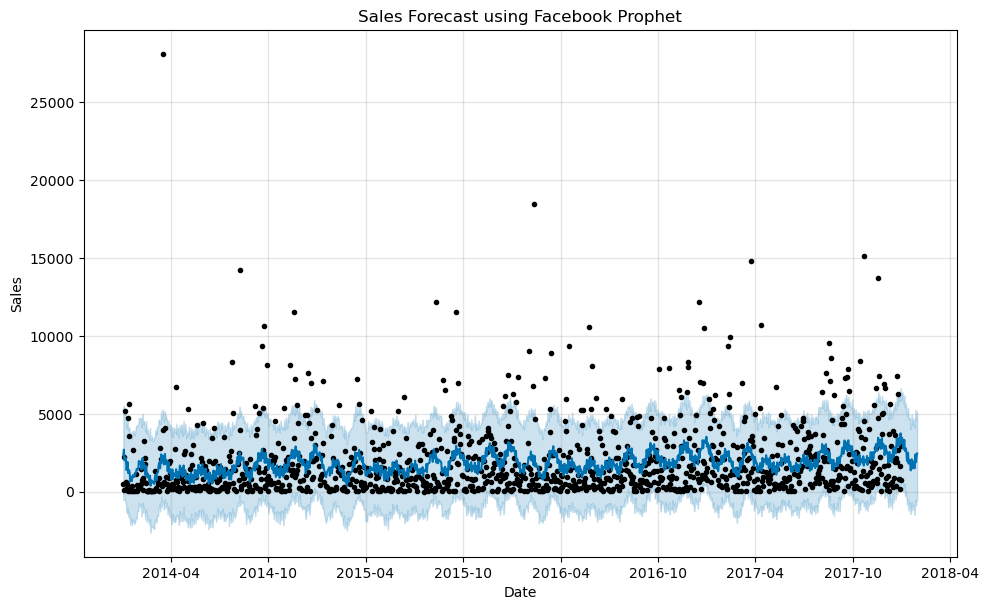

In [15]:
# Install Prophet (Run once)
# pip install prophet

import pandas as pd
from prophet import Prophet
from sklearn.metrics import mean_absolute_error
from itertools import product
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("Superstore_Final_Clean.csv")   # Change path if needed

# Convert Order Date to datetime
df["Order Date"] = pd.to_datetime(df["Order Date"])

# Aggregate daily sales
daily_sales = (
    df.groupby("Order Date")["Sales"]
    .sum()
    .reset_index()
)

# Rename columns for Prophet
daily_sales.columns = ["ds", "y"]

# Train-Test Split (Last 30 days for testing)
train = daily_sales[:-30]
test = daily_sales[-30:]

# Hyperparameter Grid
param_grid = {
    "changepoint_prior_scale": [0.001, 0.01, 0.1, 0.5],
    "seasonality_prior_scale": [1, 5, 10, 20]
}

best_mae = float("inf")
best_params = None
best_model = None

# Hyperparameter Tuning
for cps, sps in product(
    param_grid["changepoint_prior_scale"],
    param_grid["seasonality_prior_scale"]
):

    model = Prophet(
        changepoint_prior_scale=cps,
        seasonality_prior_scale=sps
    )

    model.fit(train)

    future = model.make_future_dataframe(periods=30)
    forecast = model.predict(future)

    predictions = forecast[["ds", "yhat"]]
    results = test.merge(predictions, on="ds")

    mae = mean_absolute_error(results["y"], results["yhat"])

    print(f"CPS={cps}, SPS={sps}, MAE={mae:.2f}")

    if mae < best_mae:
        best_mae = mae
        best_params = (cps, sps)
        best_model = model

print("\nBest Parameters:")
print("changepoint_prior_scale =", best_params[0])
print("seasonality_prior_scale =", best_params[1])
print("Lowest MAE =", round(best_mae, 2))

# Train Final Model on Full Dataset
final_model = Prophet(
    changepoint_prior_scale=best_params[0],
    seasonality_prior_scale=best_params[1]
)

final_model.fit(daily_sales)

# Forecast Next 30 Days
future = final_model.make_future_dataframe(periods=30)
forecast = final_model.predict(future)

# Display Forecast
print("\nNext 30 Days Forecast:")
print(forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(30))

# Plot Forecast
fig = final_model.plot(forecast)
plt.title("Sales Forecast using Facebook Prophet")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()


Files saved successfully:
  prophet_forecast.png
  forecast_components.png
  30day_forecast.csv
  prophet_model.pkl


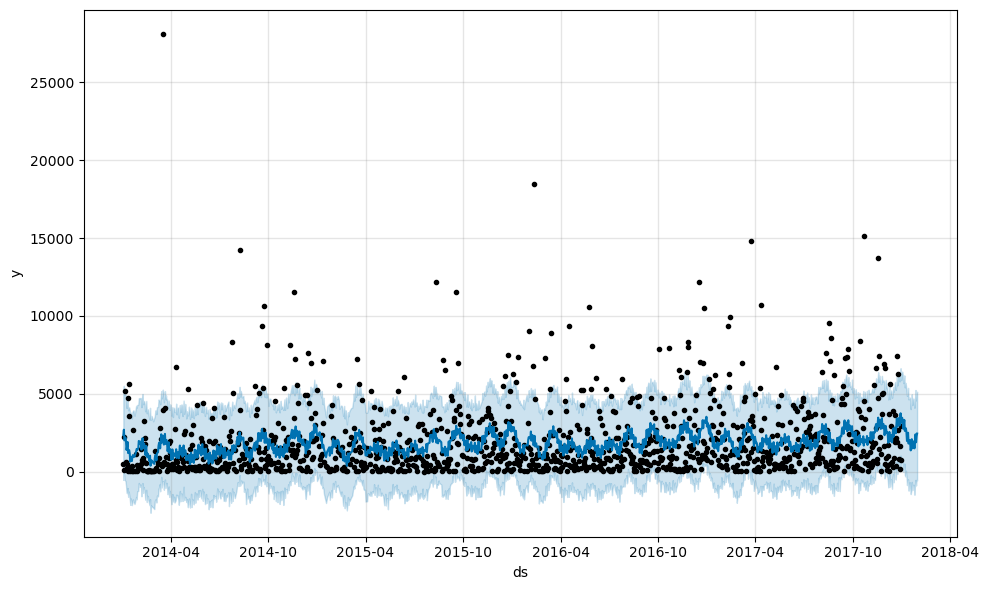

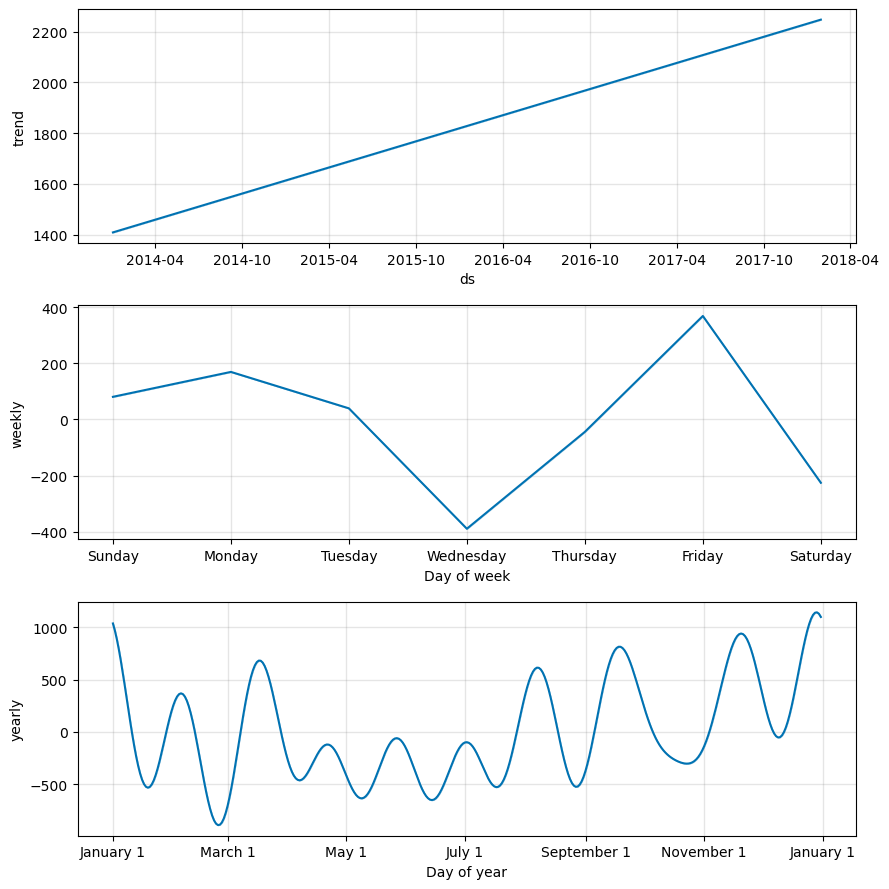

In [18]:
import pickle

# Save forecast plot
fig1 = final_model.plot(forecast)
fig1.savefig("prophet_forecast.png")

# Save components plot
fig2 = final_model.plot_components(forecast)
fig2.savefig("forecast_components.png")

# Save 30-day forecast to CSV
forecast.tail(30)[["ds", "yhat", "yhat_lower", "yhat_upper"]].to_csv(
    "30day_forecast.csv", index=False
)

# Save trained Prophet model
with open("prophet_model.pkl", "wb") as f:
    pickle.dump(final_model, f)

# Print saved files
print("\nFiles saved successfully:")
print("  prophet_forecast.png")
print("  forecast_components.png")
print("  30day_forecast.csv")
print("  prophet_model.pkl")